# Logistic Regression

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb

In [13]:
data = pd.read_csv("/content/CreditRisk.csv")
print(data)

      Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP001002    Male      No          0      Graduate            No   
1    LP001003    Male     Yes          1      Graduate            No   
2    LP001005    Male     Yes          0      Graduate           Yes   
3    LP001006    Male     Yes          0  Not Graduate            No   
4    LP001008    Male      No          0      Graduate            No   
..        ...     ...     ...        ...           ...           ...   
609  LP002978  Female      No          0      Graduate            No   
610  LP002979    Male     Yes         3+      Graduate            No   
611  LP002983    Male     Yes          1      Graduate            No   
612  LP002984    Male     Yes          2      Graduate            No   
613  LP002990  Female      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849                0.0           0           

In [14]:
data.shape

(614, 13)

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    int64  
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    int64  
dtypes: float64(3), int64(3), object(7)
memory usage: 62.5+ KB


In [16]:
data.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,0,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141,360.0,1.0,Urban,1
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267,360.0,1.0,Urban,1
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95,360.0,1.0,Urban,1
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158,360.0,0.0,Semiurban,0
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168,360.0,1.0,Urban,1
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349,360.0,1.0,Semiurban,0


In [17]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
count,614.000000,614.000000,614.000000,600.00000,564.000000,614.000000
mean,5403.459283,1621.245798,141.166124,342.00000,0.842199,0.687296
std,6109.041673,2926.248369,88.340630,65.12041,0.364878,0.463973
min,150.000000,0.000000,0.000000,12.00000,0.000000,0.000000
25%,2877.500000,0.000000,98.000000,360.00000,1.000000,0.000000
50%,3812.500000,1188.500000,125.000000,360.00000,1.000000,1.000000
75%,5795.000000,2297.250000,164.750000,360.00000,1.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000,1.000000


In [18]:
data.Loan_Status.value_counts()

,count
Loan_Status,
1,422
0,192


In [19]:
data.groupby(['Education','Loan_Status']).Education.count()

Education     Loan_Status
Graduate      0              140
              1              340
Not Graduate  0               52
              1               82
Name: Education, dtype: int64

<Axes: xlabel='Loan_Status', ylabel='Credit_History'>

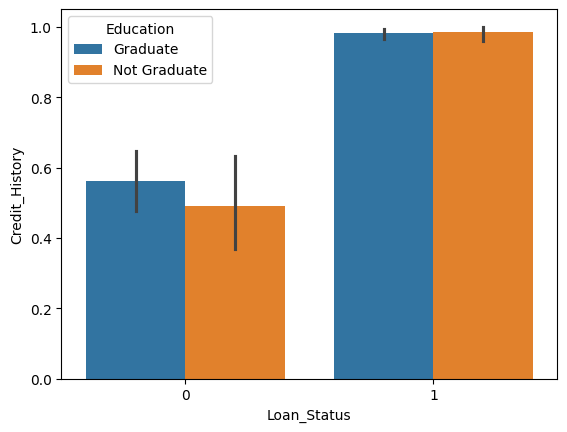

In [20]:
sb.barplot(y = "Credit_History",x = "Loan_Status",hue = "Education",data = data)



```
# This is formatted as code
```

### Filling the Null Values

In [21]:
data.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,14


In [22]:
data = data.drop(data.columns[0],axis=1)
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,0,360.0,1.0,Urban,1
1,Male,Yes,1,Graduate,No,4583,1508.0,128,360.0,1.0,Rural,0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66,360.0,1.0,Urban,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120,360.0,1.0,Urban,1
4,Male,No,0,Graduate,No,6000,0.0,141,360.0,1.0,Urban,1


In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    int64  
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    int64  
dtypes: float64(3), int64(3), object(6)
memory usage: 57.7+ KB


In [24]:
#Segregetting the columns into the different category
data_object = data.select_dtypes(include=['object']).columns
data_numeric = data.select_dtypes(exclude=['object']).columns

In [25]:
print(data_object)
print(data_numeric)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='object')
Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Loan_Status'],
      dtype='object')


In [26]:
#Impute
for columns in data_object:
    majority = data[columns].value_counts().iloc[0]
    data.fillna(majority, inplace = True)

In [27]:
for columns in data_numeric:
    majority = data[columns].value_counts().iloc[0]
    data.fillna(majority, inplace = True)

In [41]:
data.isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


In [33]:
df_dummy = pd.get_dummies(data, columns = data_object)
df_dummy.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_489,Gender_Female,Gender_Male,Married_489,...,Dependents_2,Dependents_3+,Education_Graduate,Education_Not Graduate,Self_Employed_489,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,0,360.0,1.0,1,False,False,True,False,...,False,False,True,False,False,True,False,False,False,True
1,4583,1508.0,128,360.0,1.0,0,False,False,True,False,...,False,False,True,False,False,True,False,True,False,False
2,3000,0.0,66,360.0,1.0,1,False,False,True,False,...,False,False,True,False,False,False,True,False,False,True
3,2583,2358.0,120,360.0,1.0,1,False,False,True,False,...,False,False,False,True,False,True,False,False,False,True
4,6000,0.0,141,360.0,1.0,1,False,False,True,False,...,False,False,True,False,False,True,False,False,False,True


In [29]:
  from sklearn.model_selection import train_test_split # For splitting the dataset into training and testing sets
  from sklearn.linear_model import LogisticRegression	# For logistic regression model
  from sklearn.metrics import accuracy_score, confusion_matrix, classification_report	# For evaluating performance


In [34]:
X = df_dummy.drop('Loan_Status', axis = 1)
y = df_dummy.Loan_Status

train_x, test_x, train_y, test_y = train_test_split(X, y, test_size = 0.3, random_state=42)

train_x.shape, test_x.shape
model = LogisticRegression(max_iter=1000)
model.fit(train_x, train_y)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [38]:
y_pred = model.predict(test_x)

# Calculate accuracy
accuracy = accuracy_score(test_y, y_pred)
print(f"Accuracy: {accuracy}")

# Generate the confusion matrix
conf_matrix = confusion_matrix(test_y, y_pred)

print("Confusion Matrix:")
print(conf_matrix)


Accuracy: 0.6216216216216216
Confusion Matrix:
[[  3  62]
 [  8 112]]


In [40]:
# Generate the classification report
class_report = classification_report(test_y, y_pred)

print("Classification Report:")
print(class_report)


Classification Report:
              precision    recall  f1-score   support

           0       0.27      0.05      0.08        65
           1       0.64      0.93      0.76       120

    accuracy                           0.62       185
   macro avg       0.46      0.49      0.42       185
weighted avg       0.51      0.62      0.52       185

